Train: 404, Test: 102
Train after outlier removal: 319

=== MinMax + MSE ===
Epoch      0 | Loss: 0.098362
Epoch    100 | Loss: 0.077770
Epoch    200 | Loss: 0.068887
Epoch    300 | Loss: 0.061750
Epoch    400 | Loss: 0.055914
Epoch    500 | Loss: 0.051138
Epoch    600 | Loss: 0.047232
Epoch    700 | Loss: 0.044036
Epoch    800 | Loss: 0.041421
Epoch    900 | Loss: 0.039281
Epoch   1000 | Loss: 0.037531
Epoch   1100 | Loss: 0.036099
Epoch   1200 | Loss: 0.034927
Epoch   1300 | Loss: 0.033969
Epoch   1400 | Loss: 0.033184
Epoch   1500 | Loss: 0.032543
Epoch   1600 | Loss: 0.032018
Epoch   1700 | Loss: 0.031588
Epoch   1800 | Loss: 0.031237
Epoch   1900 | Loss: 0.030950
Epoch   2000 | Loss: 0.030715
Epoch   2100 | Loss: 0.030522
Epoch   2200 | Loss: 0.030365
Epoch   2300 | Loss: 0.030236
Converged at epoch 2385 | Loss: 0.030145

=== MinMax + MAE ===
Epoch      0 | Loss: 0.384117
Epoch    100 | Loss: 0.213045
Epoch    200 | Loss: 0.202033
Epoch    300 | Loss: 0.191413
Epoch    400 | Loss:

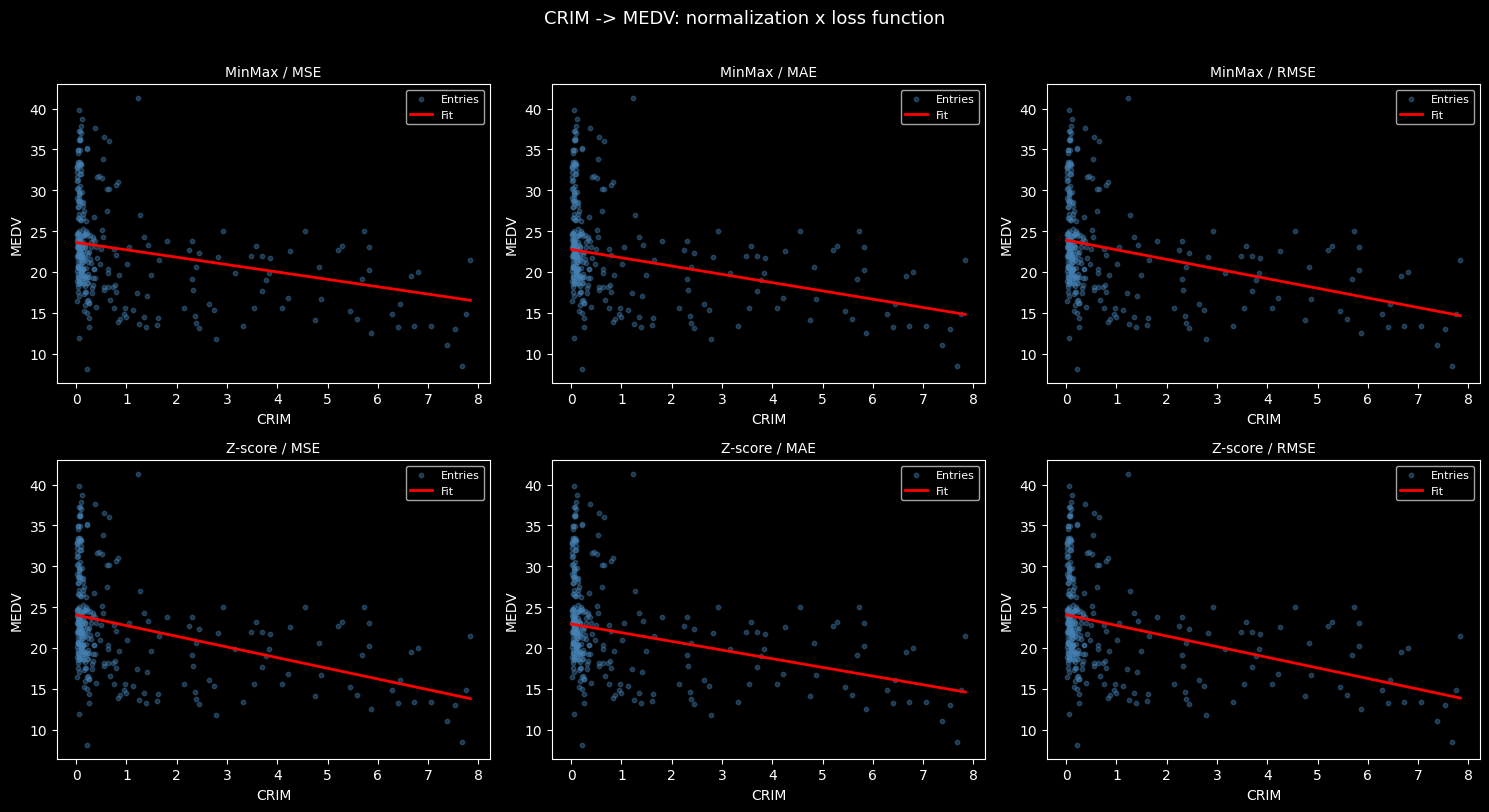


Norm       Loss          MSE        MAE       RMSE
--------------------------------------------------
MinMax     MSE       69.6253     5.3421     8.3442
MinMax     MAE       79.7235     5.5348     8.9288
MinMax     RMSE      88.0801     5.8713     9.3851
Z-score    MSE       99.8441     6.1996     9.9922
Z-score    MAE       82.5599     5.6308     9.0862
Z-score    RMSE      99.0840     6.1809     9.9541


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(seed=42)


class MinMaxNormalizer:
    def fit(self, x):
        self.min = x.min()
        self.max = x.max()
        return self

    def transform(self, x):
        return (x - self.min) / (self.max - self.min)

    def inverse(self, x):
        return x * (self.max - self.min) + self.min

    def fit_transform(self, x):
        return self.fit(x).transform(x)


class ZScoreNormalizer:
    def fit(self, x):
        self.mean = x.mean()
        self.std = x.std()
        return self

    def transform(self, x):
        return (x - self.mean) / self.std

    def inverse(self, x):
        return x * self.std + self.mean

    def fit_transform(self, x):
        return self.fit(x).transform(x)


class MSELoss:
    def loss(self, y, y_pred):
        return ((y_pred - y) ** 2).mean()

    def grad(self, X, y, y_pred):
        error = y_pred - y
        w_grad = (2 * error * X).mean()
        b_grad = (2 * error).mean()
        return w_grad, b_grad


class MAELoss:
    def loss(self, y, y_pred):
        return np.abs(y_pred - y).mean()

    def grad(self, X, y, y_pred):
        error = y_pred - y
        w_grad = (np.sign(error) * X).mean()
        b_grad = (np.sign(error)).mean()
        return w_grad, b_grad


class RMSELoss:
    def __init__(self):
        self._mse = MSELoss()

    def loss(self, y, y_pred):
        return self._mse.loss(y, y_pred) ** 0.5

    def grad(self, X, y, y_pred):
        l = self._mse.loss(y, y_pred)
        w_grad, b_grad = self._mse.grad(X, y, y_pred)
        scale = 1 / (2 * l ** 0.5)
        return scale * w_grad, scale * b_grad


def linear(X, weight, bias):
    return weight * X + bias


def train_model(x, y, loss_fn, learning_rate, snapshot_every=100, tol=1e-6, patience=10):
    weight, bias = rng.uniform(), rng.uniform()
    prev_loss = float("inf")
    no_improve = 0
    epoch = 0

    while True:
        y_pred = linear(x, weight, bias)
        l = loss_fn.loss(y, y_pred)
        w_grad, b_grad = loss_fn.grad(x, y, y_pred)
        weight -= learning_rate * w_grad
        bias -= learning_rate * b_grad

        if epoch % snapshot_every == 0:
            print(f"Epoch {epoch:>6} | Loss: {l:.6f}")

        if abs(prev_loss - l) < tol:
            no_improve += 1
            if no_improve >= patience:
                print(f"Converged at epoch {epoch} | Loss: {l:.6f}")
                break
        else:
            no_improve = 0

        prev_loss = l
        epoch += 1

        if epoch > 10000:
            break

    return weight, bias

def plot_fit(ax, norm_x, norm_y, weight, bias, norm_label, loss_label, predict_col, norm_x_obj, norm_y_obj):
    x_line = np.linspace(norm_x.min(), norm_x.max(), 200)
    y_line = linear(x_line, weight, bias)
    ax.scatter(norm_x_obj.inverse(norm_x), norm_y_obj.inverse(norm_y), s=10, alpha=0.4, color="steelblue", label="Entries")
    ax.plot(norm_x_obj.inverse(x_line), norm_y_obj.inverse(y_line), color="red", linewidth=2, label="Fit")
    ax.set_title(f"{norm_label} / {loss_label}", fontsize=10)
    ax.set_xlabel(predict_col)
    ax.set_ylabel("MEDV")
    ax.legend(fontsize=8)

def remove_outliers_iqr(df, col, k=1.5):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] >= q1 - k * iqr) & (df[col] <= q3 + k * iqr)
    return df[mask].reset_index(drop=True)


column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

data = pd.read_csv("data/housing.csv", names=column_names, delimiter=r"\s+")
train, test = train_test_split(data, test_size=0.2, random_state=42)

print(f"Train: {len(train)}, Test: {len(test)}")

train = remove_outliers_iqr(train, 'CRIM')
train = remove_outliers_iqr(train, 'MEDV')

print(f"Train after outlier removal: {len(train)}")

learning_rate = 0.01

PREDICT = 'CRIM'
PRICE = 'MEDV'

raw_x = train[PREDICT]
raw_y = train[PRICE]

norm_x_minmax = MinMaxNormalizer().fit(raw_x)
norm_y_minmax = MinMaxNormalizer().fit(raw_y)

norm_x_zscore = ZScoreNormalizer().fit(raw_x)
norm_y_zscore = ZScoreNormalizer().fit(raw_y)

loss_fns = [
    ("MSE",  MSELoss()),
    ("MAE",  MAELoss()),
    ("RMSE", RMSELoss()),
]

normalizations = [
    ("MinMax",  norm_x_minmax, norm_y_minmax),
    ("Z-score", norm_x_zscore, norm_y_zscore),
]

fig, axes = plt.subplots(len(normalizations), len(loss_fns), figsize=(5 * len(loss_fns), 4 * len(normalizations)))

trained_weights = {}

for i, (norm_label, norm_x_obj, norm_y_obj) in enumerate(normalizations):
    norm_x = norm_x_obj.transform(raw_x)
    norm_y = norm_y_obj.transform(raw_y)
    for j, (loss_label, loss_fn) in enumerate(loss_fns):
        print(f"\n=== {norm_label} + {loss_label} ===")
        weight, bias = train_model(
            norm_x, norm_y,
            loss_fn,
            learning_rate,
            snapshot_every=100,
        )
        trained_weights[(norm_label, loss_label)] = (weight, bias)
        plot_fit(axes[i, j], norm_x, norm_y, weight, bias, norm_label, loss_label, PREDICT, norm_x_obj, norm_y_obj)

plt.suptitle(f"{PREDICT} -> {PRICE}: normalization x loss function", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fits.png", dpi=150, bbox_inches="tight")
plt.show()

test_x_raw = test[PREDICT].values
test_y_raw = test[PRICE].values

print(f"\n{'Norm':<10} {'Loss':<6} {'MSE':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 50)

for norm_label, norm_x_obj, norm_y_obj in normalizations:
    test_x_norm = norm_x_obj.transform(test_x_raw)

    for loss_label, loss_fn in loss_fns:
        weight, bias = trained_weights[(norm_label, loss_label)]

        test_y_pred = norm_y_obj.inverse(linear(test_x_norm, weight, bias))

        mse  = MSELoss().loss(test_y_raw, test_y_pred)
        mae  = MAELoss().loss(test_y_raw, test_y_pred)
        rmse = RMSELoss().loss(test_y_raw, test_y_pred)

        print(f"{norm_label:<10} {loss_label:<6} {mse:>10.4f} {mae:>10.4f} {rmse:>10.4f}")